# asymptotics — Non-Standard Gauge Sequences

In classical perturbation theory the standard ansatz assumes a power series in $\varepsilon$:

$$x(\varepsilon) = x_0 + \varepsilon\, x_1 + \varepsilon^2\, x_2 + \cdots$$

But many problems require a **different asymptotic scale** — when the solution is not analytic in $\varepsilon$.  The general form is

$$x(\varepsilon) = x_0\,\delta_0(\varepsilon) + x_1\,\delta_1(\varepsilon) + x_2\,\delta_2(\varepsilon) + \cdots$$

where $\{\delta_k(\varepsilon)\}$ is any **asymptotic sequence** satisfying $\delta_{k+1}/\delta_k \to 0$ as $\varepsilon\to 0$.

`asymptotics` supports arbitrary gauge sequences via the `gauge=` keyword on `expand_regular()`.

| `gauge=` value | Sequence generated |
|:--------------|:-------------------|
| `None` (default) | $\{1,\varepsilon,\varepsilon^2,\ldots\}$ |
| `'sqrt(eps)'` | $\{1,\sqrt\varepsilon,\varepsilon,\varepsilon^{3/2},\ldots\}$ — inferred geometrically |
| `'eps**(1/3)'` | $\{1,\varepsilon^{1/3},\varepsilon^{2/3},\varepsilon,\ldots\}$ — inferred geometrically |
| `['1','eps*log(eps)','eps']` | $\{1,\varepsilon\ln\varepsilon,\varepsilon\}$ — explicit list, required for non-geometric sequences |


In [1]:
from asymptotics import AlgebraicEquation, ODE
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

---
## Example 1 — Branch point: $x^2 = \varepsilon$

The equation $x^2 - \varepsilon = 0$ has the exact solution $x = \sqrt{\varepsilon}$.

**Why the standard gauge fails:** substituting $x = x_0 + \varepsilon x_1 + \cdots$ gives

$$O(1):\; x_0^2 = 0 \;\Rightarrow\; x_0 = 0 \qquad O(\varepsilon):\; -1 = 0 \quad \textbf{contradiction!}$$

The solution has a *branch point* at $\varepsilon = 0$ — it is not analytic in $\varepsilon$, only in $\sqrt\varepsilon$.
The correct gauge is $\{\sqrt\varepsilon,\, \varepsilon,\, \varepsilon^{3/2},\ldots\}$.


In [2]:
eq = AlgebraicEquation("x**2 - eps", dependent="x", small_param="eps")

# Standard gauge fails — show the error
try:
    eq.expand_regular(order=2)
except Exception as e:
    print("Standard gauge failed (expected):")
    for line in str(e).strip().splitlines():
        if line.strip():
            print(" ", line.strip())
            break

Standard gauge failed (expected):
  Could not solve the order-1 equation for x_1:


In [3]:
# Correct: explicit gauge starting at sqrt(eps)
sol = eq.expand_regular(order=2, gauge=["sqrt(eps)", "eps", "eps**(3/2)"])
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

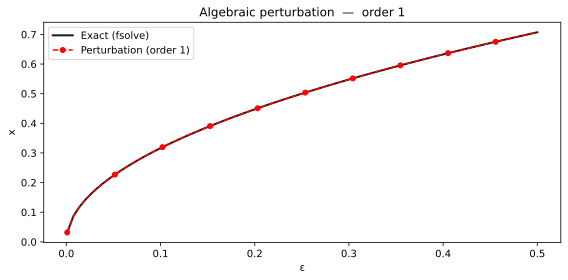

In [4]:
sol.compare_numeric(eps=list(np.linspace(0.001, 0.5, 80)))
plt.show()

---
## Example 2 — Mixed gauge: $x^2 + \sqrt\varepsilon\, x - 1 = 0$

The equation $x^2 + \sqrt\varepsilon\, x - 1 = 0$ has an exact solution involving $\sqrt\varepsilon$:

$$x = \frac{-\sqrt\varepsilon + \sqrt{\varepsilon + 4}}{2} = 1 - \frac{\sqrt\varepsilon}{2} + \frac{\varepsilon}{8} - \frac{\varepsilon^{3/2}}{16} + \cdots$$

**Standard gauge fails** again: the $O(1)$ equation gives $x_0 = 1$, but the $O(\varepsilon)$ equation has no $x_1$ in it (the perturbation is $O(\sqrt\varepsilon)$, not $O(\varepsilon)$), producing a contradiction.

The correct gauge is $\{1, \sqrt\varepsilon, \varepsilon, \varepsilon^{3/2}, \ldots\}$, captured by `gauge='sqrt(eps)'`.


In [5]:
eq = AlgebraicEquation("x**2 + sqrt(eps)*x - 1", dependent="x", small_param="eps")

# Standard gauge fails
try:
    eq.expand_regular(order=3)
except Exception as e:
    print("Standard gauge failed (expected):")
    for line in str(e).strip().splitlines():
        if line.strip():
            print(" ", line.strip())
            break

Standard gauge failed (expected):
  Could not solve the order-1 equation for x_1:


In [6]:
# String pattern 'sqrt(eps)' infers {1, sqrt(eps), eps, eps^(3/2), ...}
sol = eq.expand_regular(order=3, gauge="sqrt(eps)")
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

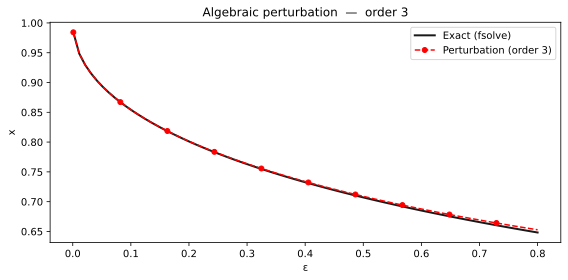

In [7]:
sol.compare_numeric(eps=list(np.linspace(0.001, 0.8, 80)))
plt.show()

---
## Example 3 — Logarithmic gauge: $x(1 + \varepsilon\ln\varepsilon) = 1$

Logarithmic terms $\varepsilon\ln\varepsilon$ arise naturally in 2D Stokes flow past a cylinder, and in eigenvalue problems near singular points.  This gauge is **not** geometric — `eps*log(eps)` grows slower than any power of `eps`, so the sequence $\{1, \varepsilon\ln\varepsilon, \varepsilon\}$ cannot be generated from a string pattern.  You must supply an **explicit list**.

The equation $x + \varepsilon\ln(\varepsilon)\cdot x - 1 = 0$ has exact solution $x = 1/(1 + \varepsilon\ln\varepsilon)$.

**Standard gauge:** gives $x \approx 1$ — the logarithmic correction is completely invisible.

**Log gauge** $\{1,\, \varepsilon\ln\varepsilon,\, \varepsilon\}$: correctly gives $x \approx 1 - \varepsilon\ln\varepsilon$.


In [8]:
eq = AlgebraicEquation("x + eps*log(eps)*x - 1", dependent="x", small_param="eps")

# Standard gauge: eps*log(eps) -> -inf as eps->0, so series expansion breaks
try:
    eq.expand_regular(order=2)
except Exception as e:
    print("Standard gauge failed (expected):")
    for line in str(e).strip().splitlines():
        if line.strip():
            print(" ", line.strip())
            break

Standard gauge failed (expected):
  Could not solve the order-1 equation for x_1:


In [9]:
# Explicit log gauge — must be a list, not a string pattern
sol = eq.expand_regular(order=2, gauge=["1", "eps*log(eps)", "eps"])
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

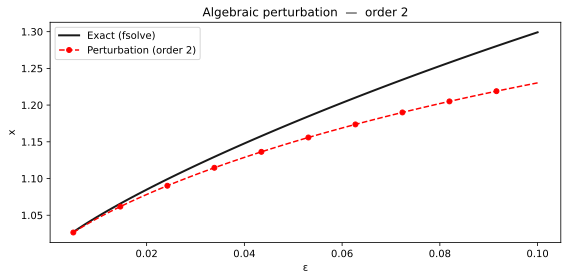

In [11]:
sol.compare_numeric(eps=list(np.linspace(0.005, 0.1, 80)))
plt.show()

---
## Example 4 — ODE with $\sqrt\varepsilon$ perturbation

Gauge sequences apply equally to ODEs.  Consider

$$u'' + u + \sqrt\varepsilon\, u^2 = 0, \quad u(0) = 1,\quad u'(0) = 0$$

The perturbation is $O(\sqrt\varepsilon)$, so the natural ansatz is

$$u = u_0(t) + \sqrt\varepsilon\; u_1(t) + \varepsilon\; u_2(t) + \cdots$$

The standard gauge would fail: the $O(\varepsilon)$ equation contains no $u_1$ since the nonlinear term is $O(\sqrt\varepsilon)$, leading to $0 = 0$ at $O(\varepsilon)$ while the actual $O(\sqrt\varepsilon)$ correction goes unresolved.


In [12]:
eq = ODE("u'' + u + eps**(1/2)*u**2", small_param="eps",
         conditions=["u(0)=1", "u'(0)=0"])

sol = eq.expand_regular(order=2, gauge="sqrt(eps)")
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

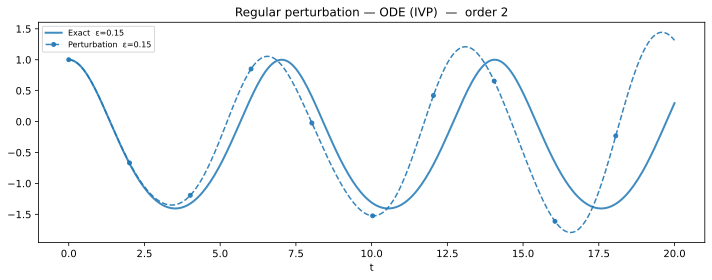

In [13]:
sol.compare_numeric(eps=0.15, plot_range=[0, 20])
plt.show()

---
## Summary

In every example above, the **standard gauge fails** — either with an outright contradiction or by producing a flat `x ≈ constant` that misses the dominant correction.  A non-standard gauge is not a convenience; it is a **necessity** when the solution has a branch point or logarithmic singularity in $\varepsilon$.

| Equation feature | Standard gauge result | Correct gauge |
|:----------------|:---------------------|:--------------|
| $x^n = \varepsilon$ (branch point) | Contradiction at $O(\varepsilon)$ | `['eps**(1/n)', ...]` explicit |
| $f + \sqrt\varepsilon\,g = 0$ | Contradiction at $O(\varepsilon)$ | `gauge='sqrt(eps)'` |
| $\varepsilon\ln\varepsilon$ term | Correction invisible | `['1','eps*log(eps)','eps']` explicit |

**Format rule:** use a **string** for geometric sequences (ratio is constant), use an **explicit list** for non-geometric sequences (logarithmic).  The list must have exactly `order + 1` terms.
